# Supervised Learning Project on Heart Failure Prediction with KNN

### 1. Introduction & Setup

This project aims to build a K-Nearest Neighbors (KNN) classifier to predict mortality in patients with heart failure. The model will be trained on the "Heart Failure Prediction" dataset.

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, roc_auc_score
from sklearn.impute import SimpleImputer

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')

### 2. Data Preparation

In [16]:
file_path = '../data/heart_disease_uci.csv' 
df = pd.read_csv(file_path)

In [18]:
print("First 5 rows of the dataset:")
print(df.head())

print("\nDataset Information:")
df.info()

print("\nDescriptive Statistics:")
print(df.describe())
print(f"\nDataset shape: {df.shape}")


First 5 rows of the dataset:
   id  age     sex    dataset               cp  trestbps   chol    fbs  \
0   1   63    Male  Cleveland   typical angina     145.0  233.0   True   
1   2   67    Male  Cleveland     asymptomatic     160.0  286.0  False   
2   3   67    Male  Cleveland     asymptomatic     120.0  229.0  False   
3   4   37    Male  Cleveland      non-anginal     130.0  250.0  False   
4   5   41  Female  Cleveland  atypical angina     130.0  204.0  False   

          restecg  thalch  exang  oldpeak        slope   ca  \
0  lv hypertrophy   150.0  False      2.3  downsloping  0.0   
1  lv hypertrophy   108.0   True      1.5         flat  3.0   
2  lv hypertrophy   129.0   True      2.6         flat  2.0   
3          normal   187.0  False      3.5  downsloping  0.0   
4  lv hypertrophy   172.0  False      1.4    upsloping  0.0   

                thal  num  
0       fixed defect    0  
1             normal    2  
2  reversable defect    1  
3             normal    0  
4      

###  3. Data Cleaning and Preprocessing

In [ ]:
df_cleaned = df.drop(['id', 'dataset'], axis=1)

df_cleaned['target'] = (pd.to_numeric(df_cleaned['num'], errors='coerce') > 0).astype(int)
df_cleaned = df_cleaned.drop('num', axis=1)

In [ ]:
X = df_cleaned.drop('target', axis=1)
y = df_cleaned['target']

numeric_cols = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca']
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']

for col in numeric_cols:
    X[col] = pd.to_numeric(X[col], errors='coerce')

X_processed = pd.get_dummies(X, columns=categorical_cols, dummy_na=True, drop_first=True)

print("\nShape of features after one-hot encoding:", X_processed.shape)
print("Columns created:", X_processed.columns)
print("\nData head after all processing:")
print(X_processed.head())


Shape of features after one-hot encoding: (920, 25)
Columns created: Index(['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca', 'sex_Male',
       'sex_nan', 'cp_atypical angina', 'cp_non-anginal', 'cp_typical angina',
       'cp_nan', 'fbs_True', 'fbs_nan', 'restecg_normal',
       'restecg_st-t abnormality', 'restecg_nan', 'exang_True', 'exang_nan',
       'slope_flat', 'slope_upsloping', 'slope_nan', 'thal_normal',
       'thal_reversable defect', 'thal_nan'],
      dtype='object')

Data head after all processing:
   age  trestbps   chol  thalch  oldpeak   ca  sex_Male  sex_nan  \
0   63     145.0  233.0   150.0      2.3  0.0      True    False   
1   67     160.0  286.0   108.0      1.5  3.0      True    False   
2   67     120.0  229.0   129.0      2.6  2.0      True    False   
3   37     130.0  250.0   187.0      3.5  0.0      True    False   
4   41     130.0  204.0   172.0      1.4  0.0     False    False   

   cp_atypical angina  cp_non-anginal  ...  restecg_st-t abnormal

### 4. Impute Missing Values

In [ ]:
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X_processed)

X_final = pd.DataFrame(X_imputed, columns=X_processed.columns)

print("\nMissing values in final feature set:", X_final.isnull().sum().sum())


Missing values in final feature set: 0


### 5. Split the Data (X and Y)

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size=0.2, random_state=42, stratify=y)

print("\nShape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)


Shape of X_train: (736, 25)
Shape of X_test: (184, 25)


### 6. Standardizing data

In [28]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

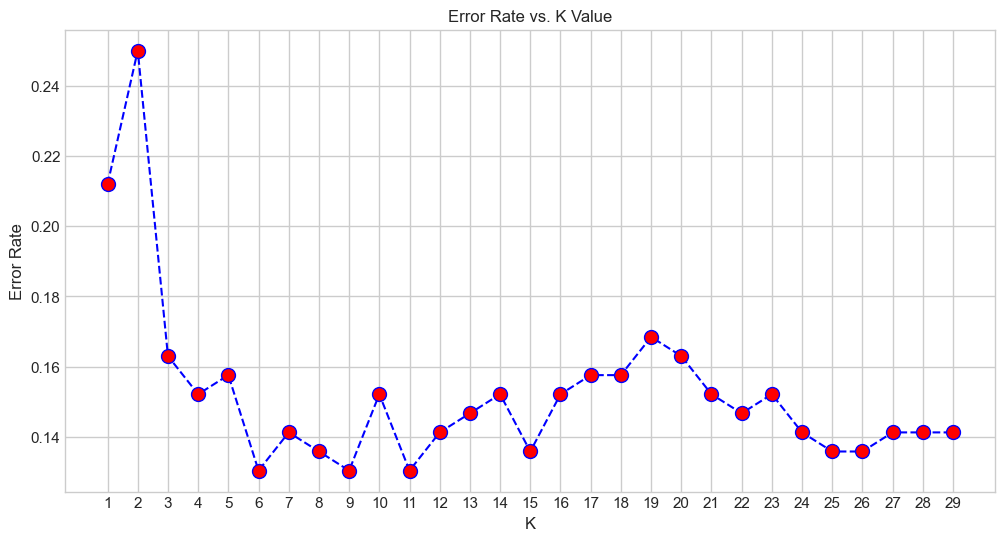


Optimal k value is: 6


In [ ]:
error_rate = []
k_range = range(1, 30) 

for i in k_range:
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train_scaled, y_train)
    pred_i = knn.predict(X_test_scaled)
    error_rate.append(np.mean(pred_i != y_test))

plt.figure(figsize=(12, 6))
plt.plot(k_range, error_rate, color='blue', linestyle='dashed', marker='o',
         markerfacecolor='red', markersize=10)
plt.title('Error Rate vs. K Value')
plt.xlabel('K')
plt.ylabel('Error Rate')
plt.xticks(k_range)
plt.grid(True)
plt.show()

optimal_k = k_range[np.argmin(error_rate)]
print(f"\nOptimal k value is: {optimal_k}")

### 7. Train the KNN Model

In [33]:
k = 6

knn_model = KNeighborsClassifier(n_neighbors=k)
knn_model.fit(X_train_scaled, y_train)

print(f"\nKNN model trained with k={k}")


KNN model trained with k=6


### 8. Model evaluation


Model Accuracy: 0.8696

Classification Report:
                precision    recall  f1-score   support

No Disease (0)       0.87      0.83      0.85        82
   Disease (1)       0.87      0.90      0.88       102

      accuracy                           0.87       184
     macro avg       0.87      0.87      0.87       184
  weighted avg       0.87      0.87      0.87       184



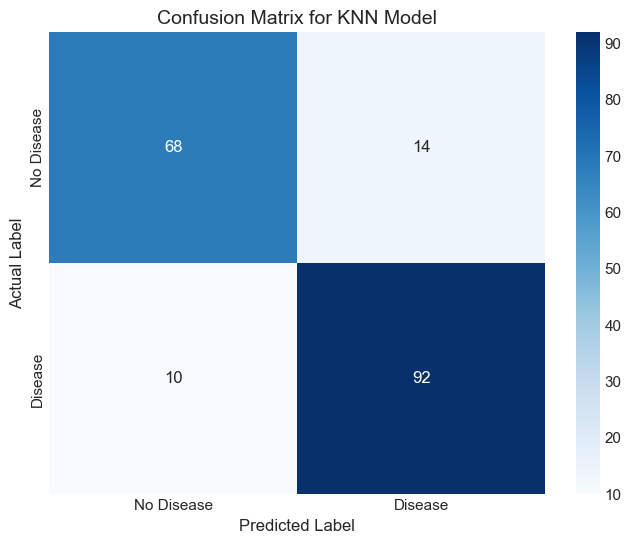

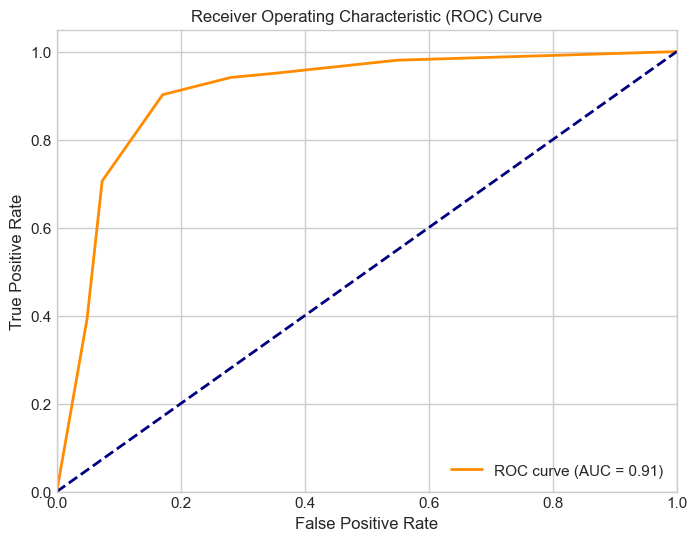

In [34]:
y_pred = knn_model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
print(f"\nModel Accuracy: {accuracy:.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['No Disease (0)', 'Disease (1)']))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
plt.title('Confusion Matrix for KNN Model', fontsize=14)
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

y_pred_proba = knn_model.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc_score = roc_auc_score(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()